LAB 5

EXPERIMENT 1: NAÏVE BAYES

Q1. Load dataset and display structure

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.head())
print(df.info())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

Q2. Split dataset into training and testing (80:20)

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (455, 30)
Testing Shape: (114, 30)


Q3. Train Naïve Bayes classifier

In [3]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

Q4. Predict class labels

In [4]:
nb_pred = nb_model.predict(X_test)
nb_pred_proba = nb_model.predict_proba(X_test)[:, 1]

Q5. Evaluate model performance

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, nb_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, nb_pred))

print("\nClassification Report:\n",
      classification_report(y_test, nb_pred, target_names=data.target_names))

Accuracy: 0.9736842105263158

Confusion Matrix:
 [[40  3]
 [ 0 71]]

Classification Report:
               precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        43
      benign       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Q6. Precision-Recall Curve

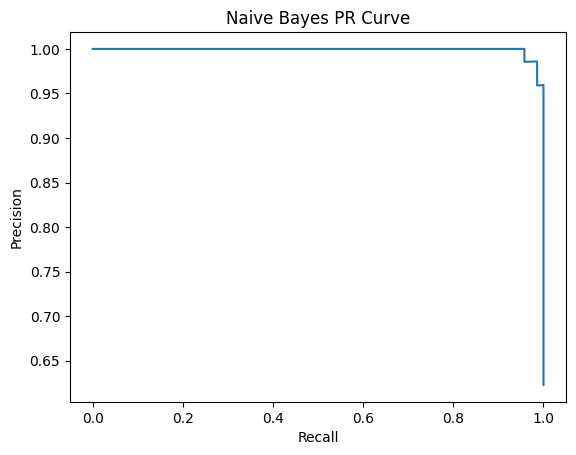

In [6]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, nb_pred_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Naive Bayes PR Curve")
plt.show()

**EXPERIMENT 2: DECISION TREE**

Q1. Load dataset (reuse previous)

In [7]:
# X and y already created

Q2. Train Decision Tree model

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Q3. Predict test data

In [9]:
dt_pred = dt_model.predict(X_test)
dt_pred_proba = dt_model.predict_proba(X_test)[:, 1]

Q4. Evaluate model

In [10]:
print("Accuracy:", accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, dt_pred))

print("\nClassification Report:\n",
      classification_report(y_test, dt_pred, target_names=data.target_names))

Accuracy: 0.9473684210526315

Confusion Matrix:
 [[40  3]
 [ 3 68]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



Q5. Precision-Recall Curve

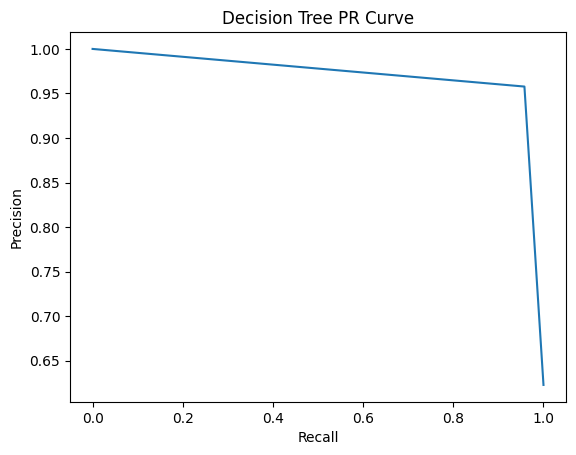

In [11]:
precision_dt, recall_dt, _ = precision_recall_curve(y_test, dt_pred_proba)

plt.plot(recall_dt, precision_dt)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Decision Tree PR Curve")
plt.show()

Q6. Visualize Decision Tree

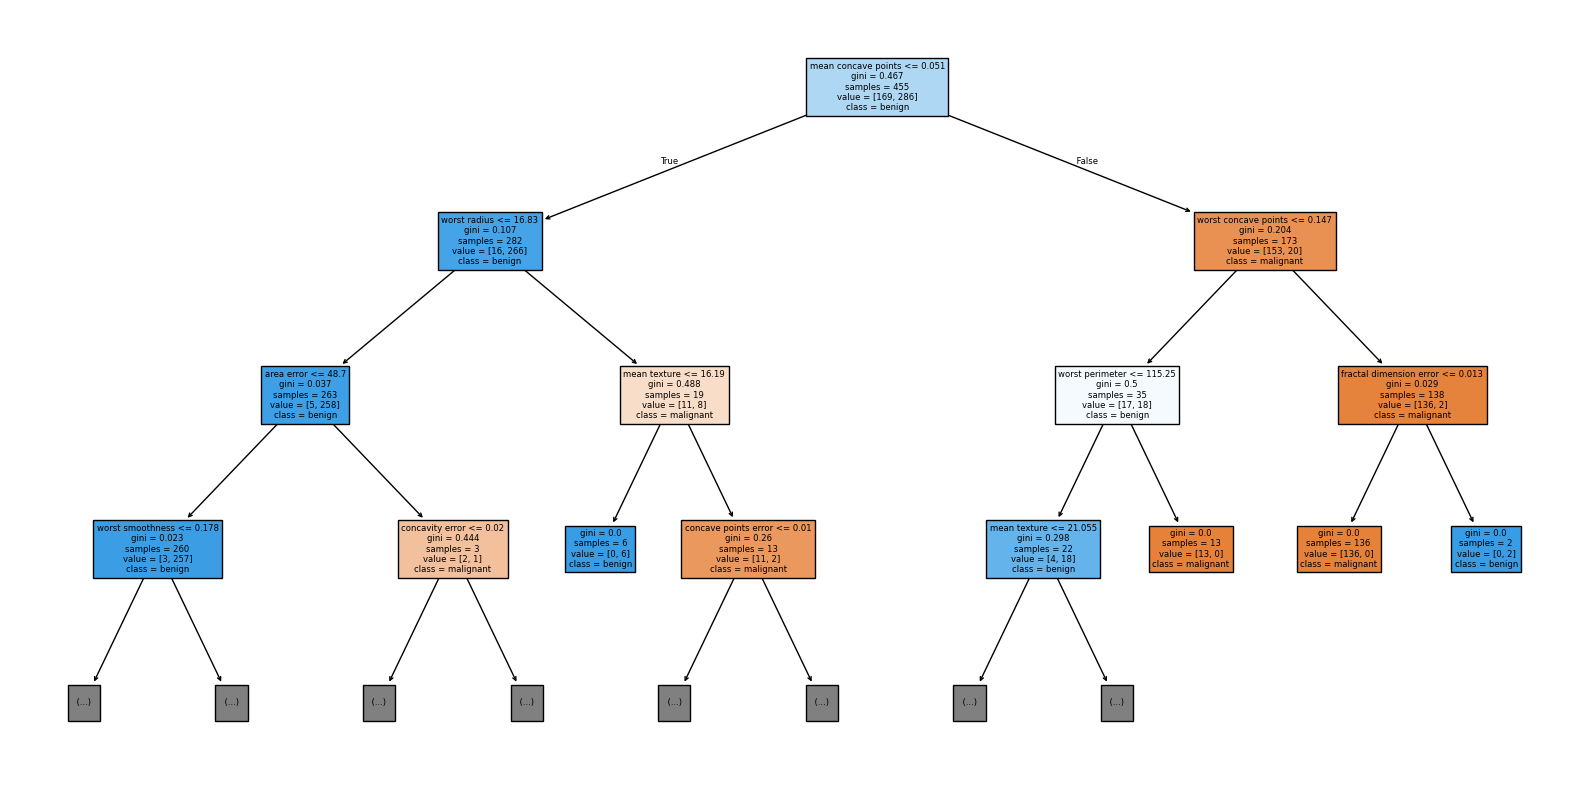

In [12]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt_model,
          filled=True,
          feature_names=data.feature_names,
          class_names=data.target_names,
          max_depth=3)

plt.show()

**EXPERIMENT 3: MODEL COMPARISON**

Q1. Compare accuracy (Bar Chart)

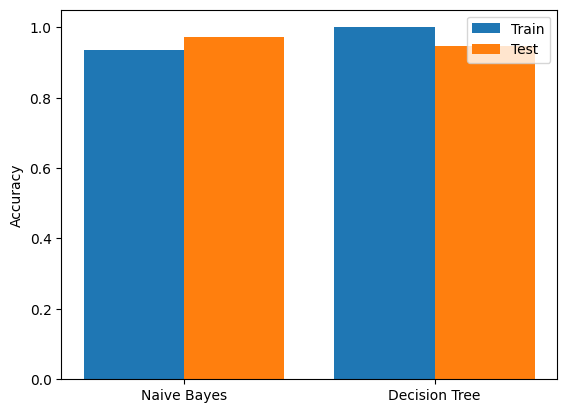

In [13]:
labels = ['Naive Bayes', 'Decision Tree']
train_acc = [
    accuracy_score(y_train, nb_model.predict(X_train)),
    accuracy_score(y_train, dt_model.predict(X_train))
]
test_acc = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, dt_pred)
]

import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(labels))

plt.bar(x-0.2, train_acc, 0.4, label='Train')
plt.bar(x+0.2, test_acc, 0.4, label='Test')

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Q2. ROC Curve Comparison

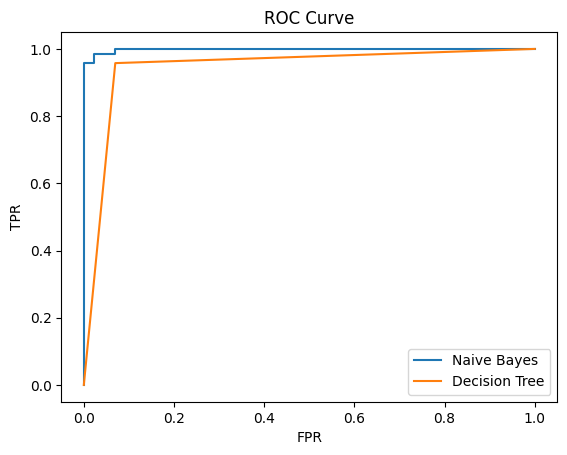

In [14]:
from sklearn.metrics import roc_curve, auc

fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_pred_proba)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_pred_proba)

plt.plot(fpr_nb, tpr_nb, label="Naive Bayes")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.legend()
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

Q3. Confusion Matrix Heatmaps

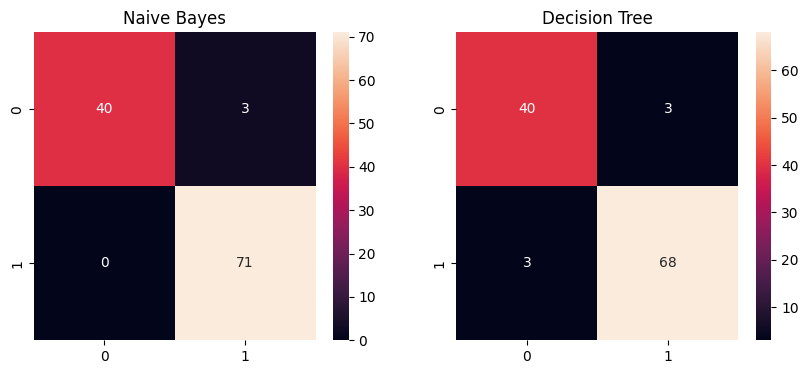

In [15]:
import seaborn as sns

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test, nb_pred), annot=True)
plt.title("Naive Bayes")

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True)
plt.title("Decision Tree")

plt.show()